In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# 1. Hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Usando: {device}")

# 2. Semilla
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
seed_everything(42)

✅ Usando: cuda


In [8]:
df = pd.read_csv(r"C:\Users\julia\MGEO\THESIS\DEFORMATION_DATA\culstered_landslides_forNN_withRainfall\MedellinOriental_with_rainfall.csv")


In [9]:
from scipy.signal import savgol_filter

def apply_savgol(x):
    # window_length: Tamaño de la ventana (debe ser impar, ej. 15)
    # polyorder: Orden del polinomio (ej. 2 o 3 para curvas suaves)
    try:
        if len(x) > 15: # Solo aplicar si la serie es suficientemente larga
            return savgol_filter(x, window_length=10, polyorder=2)
    except:
        pass
    return x

# Aplicar a cada grupo
df['u'] = df.groupby(['X', 'Y'])['u'].transform(apply_savgol)

In [10]:

df = df.sort_values(by=['X', 'Y', 't_days']).reset_index(drop=True)

# Features
feature_cols = ['u', 'X', 'Y', 'p_acum_30d', 'p_acum_60d', 'p_acum_90d', 't_days']
target_col = 'u'

# Split Temporal (Corte en día 600)
train_df_raw = df[df['t_days'] <= 600].copy()
test_df_raw = df[df['t_days'] > 600].copy()

# --- ESCALADO (StandardScaler es más robusto) ---
scaler = StandardScaler()
scaler.fit(train_df_raw[feature_cols]) # Fit solo en train

# Función que respeta los grupos X, Y
def create_sequences_grouped(df_input, n_steps_in, n_steps_out, scaler, feature_cols, target_col):
    X, y = [], []
    
    # Agrupamos por ubicación para no mezclar series
    grouped = df_input.groupby(['X', 'Y'])
    
    # Índices para numpy
    feat_indices = [df_input.columns.get_loc(c) for c in feature_cols]
    target_idx = df_input.columns.get_loc(target_col)
    
    for _, group in grouped:
        # Escalamos el grupo individualmente con el scaler global
        # (Es importante transformar aquí para mantener la estructura de grupo)
        group_scaled = scaler.transform(group[feature_cols])
        
        # Crear ventanas deslizantes dentro del grupo
        for i in range(len(group_scaled) - n_steps_in - n_steps_out + 1):
            # Input: [t : t+N]
            X.append(group_scaled[i : i + n_steps_in, :])
            # Target: [t+N : t+N+1] (solo columna u)
            # Nota: target_idx en group_scaled puede cambiar si transform devuelve solo valores
            # StandardScaler devuelve array numpy, el índice de 'u' es 0 si es la primera col en feature_cols
            y.append(group_scaled[i + n_steps_in : i + n_steps_in + n_steps_out, 0]) 
            
    return np.array(X), np.array(y)

# Parámetros
N_IN = 10  # Aumenté a 10 para darle más contexto histórico
N_OUT = 1

print("Generando secuencias...")
X_train, y_train = create_sequences_grouped(train_df_raw, N_IN, N_OUT, scaler, feature_cols, target_col)
# Para test, usamos el df completo para no perder las ventanas que cruzan el corte 600
# pero filtramos después. Por simplicidad, usaremos test_df_raw directo, 
# asumiendo que hay suficientes datos post-600 por grupo.
X_test, y_test = create_sequences_grouped(test_df_raw, N_IN, N_OUT, scaler, feature_cols, target_col)

# DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()), shuffle=True, batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float()), shuffle=False, batch_size=batch_size)

# Constantes para des-escalar (Media y Desviación Estándar)
# u es la columna 0
U_MEAN = scaler.mean_[0]
U_SCALE = scaler.scale_[0] # Esto es la desviación estándar en StandardScaler

print(f"Train shape: {X_train.shape}. U_MEAN: {U_MEAN:.4f}, U_STD: {U_SCALE:.4f}")

Generando secuencias...
Train shape: (28003, 10, 7). U_MEAN: -0.0113, U_STD: 0.0067


In [11]:
import torch.nn.functional as F

# --- CLASE DE FÍSICA (PERZYNA) ---
class SoilPhysics(nn.Module):
    def __init__(self):
        super().__init__()
        # Parámetros aprendibles
        self.c_prime_raw = nn.Parameter(torch.tensor(0.0))
        self.phi_raw = nn.Parameter(torch.tensor(0.0))
        self.n_exp_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_n_raw = nn.Parameter(torch.tensor(0.0))
        self.eta_raw = nn.Parameter(torch.tensor(0.0))
        
        # Constantes (ajusta según tu zona de estudio)
        self.h = 15.0         # metros
        self.sigma_0 = 1.0    # kPa normalización
        self.tau_fixed = 15.0 # kPa

    def get_params(self):
        return {
            "c_prime": F.softplus(self.c_prime_raw),
            "phi": F.softplus(self.phi_raw),
            "n": F.softplus(self.n_exp_raw) + 1.0,
            "sigma_n": F.softplus(self.sigma_n_raw),
            "eta": F.softplus(self.eta_raw),
            "tau": self.tau_fixed,
            "h": self.h
        }

# Función de pérdida física
def perzyna_loss_function(u_pred_mm, u_prev_mm, params, soil_physics_instance, dt_days=12.0):
    velocity = (u_pred_mm - u_prev_mm) / dt_days
    gamma_dot_kin = velocity / (params['h'] ) # h en mm
    
    phi_rad = torch.deg2rad(params['phi']) 
    yield_str = params['c_prime'] + params['sigma_n'] * torch.tan(phi_rad)
    overstress = (params['tau'] - yield_str) / soil_physics_instance.sigma_0
    
    gamma_dot_dyn = (1.0 / params['eta']) * torch.pow(torch.relu(overstress), params['n'])
    
    return torch.mean((gamma_dot_kin - gamma_dot_dyn)**2)

# --- MODELO GRU ---
class AdvancedGRU(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(AdvancedGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]) # Último paso temporal

# --- INICIALIZACIÓN ---
model = AdvancedGRU(input_size=len(feature_cols)).to(device)
soil_physics = SoilPhysics().to(device)

# Optimizador combinado (Red + Física)
optimizer = optim.Adam(list(model.parameters()) + list(soil_physics.parameters()), lr=0.001)
criterion = nn.MSELoss()

print("Modelo y Física inicializados.")

Modelo y Física inicializados.


In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Función de Evaluación Adaptada (StandardScaler) ---
def evaluate_model(loader, model, device, u_mean, u_std):
    model.eval()
    preds_mm = []
    targets_mm = []
    
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            # Predicción (escala normalizada)
            pred_s = model(X_b)
            
            # Des-escalado: x_real = (x_norm * std) + mean
            pred_mm_batch = (pred_s * u_std) + u_mean
            
            # Aseguramos dimensiones de y_b para operar
            target_mm_batch = (y_b.view(-1, 1) * u_std) + u_mean
            
            # Guardar resultados aplanados
            preds_mm.extend(pred_mm_batch.cpu().numpy().flatten())
            targets_mm.extend(target_mm_batch.cpu().numpy().flatten())
            
    return np.array(preds_mm), np.array(targets_mm)

# --- 2. Bucle de Entrenamiento ---
epochs = 50  # Puedes ajustar esto
lambda_phy = 0.0001
print_every = 5 # Imprimir cada N épocas

# Encabezado bonito
print(f"{'Epoch':<6} | {'Total Loss':<10} | {'Data Loss':<10} | {'Phy Loss':<10} | {'TEST RMSE':<10} | {'TEST R2':<10}")
print("-" * 85)

loss_history = []

for epoch in range(epochs):
    model.train()
    e_total = 0; e_data = 0; e_phy = 0
    
    for X_b, y_b in train_loader: 
        X_b, y_b = X_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        
        # 1. Forward Pass
        u_pred_scaled = model(X_b)
        
        # 2. Física (Necesitamos unidades reales: mm)
        # Des-escalamos predicción actual u(t)
        u_pred_mm = (u_pred_scaled * U_SCALE) + U_MEAN
        
        # Des-escalamos paso anterior u(t-1) (último de la secuencia de entrada)
        u_prev_scaled = X_b[:, -1, 0].view(-1, 1)
        u_prev_mm = (u_prev_scaled * U_SCALE) + U_MEAN
        
        # 3. Cálculo de Losses
        # Loss de Datos (MSE sobre valores escalados es más estable para gradientes)
        loss_d = criterion(u_pred_scaled, y_b.view(-1, 1))
        
        # Loss de Física (Perzyna)
        phys_params = soil_physics.get_params()
        loss_p = perzyna_loss_function(u_pred_mm, u_prev_mm, phys_params, soil_physics, dt_days=12.0)
        
        # Suma ponderada
        loss = loss_d + (lambda_phy * loss_p)
        
        # 4. Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Acumuladores
        e_total += loss.item()
        e_data += loss_d.item()
        e_phy += loss_p.item()

    # --- VALIDACIÓN AL FINAL DE LA ÉPOCA ---
    # Solo imprimimos cada 'print_every' épocas para no saturar la pantalla
    if (epoch + 1) % print_every == 0 or epoch == 0:
        preds_val, targets_val = evaluate_model(test_loader, model, device, U_MEAN, U_SCALE)
        
        rmse_val = np.sqrt(mean_squared_error(targets_val, preds_val))
        r2_val = r2_score(targets_val, preds_val)
        
        n_batches = len(train_loader)
        avg_total = e_total / n_batches
        avg_data = e_data / n_batches
        avg_phy = e_phy / n_batches
        
        print(f"{epoch+1:<6} | {avg_total:.5f}    | {avg_data:.5f}    | {avg_phy:.5f}    | {rmse_val:.4f}     | {r2_val:.4f}")

print("\nEntrenamiento finalizado.")

Epoch  | Total Loss | Data Loss  | Phy Loss   | TEST RMSE  | TEST R2   
-------------------------------------------------------------------------------------
1      | 0.96263    | 0.06319    | 8994.37858    | 0.0023     | 0.8789
5      | 0.10506    | 0.00821    | 968.43836    | 0.0013     | 0.9596
10     | 0.03515    | 0.00572    | 294.33178    | 0.0010     | 0.9769
15     | 0.01649    | 0.00483    | 116.57742    | 0.0010     | 0.9780
20     | 0.00941    | 0.00446    | 49.48366    | 0.0012     | 0.9691
25     | 0.00607    | 0.00394    | 21.27397    | 0.0013     | 0.9603
30     | 0.00473    | 0.00384    | 8.92780    | 0.0015     | 0.9527
35     | 0.00399    | 0.00365    | 3.48009    | 0.0014     | 0.9548
40     | 0.00371    | 0.00359    | 1.14510    | 0.0013     | 0.9613
45     | 0.00330    | 0.00327    | 0.25213    | 0.0018     | 0.9237
50     | 0.00313    | 0.00313    | 0.01891    | 0.0017     | 0.9355

Entrenamiento finalizado.



--- 📊 TEST RESULTS ---
RMSE (Root Mean Squared Error): 0.00170 mm
MAE  (Mean Absolute Error):     0.00137 mm
R²   (Coefficient of Determ.):  0.9355


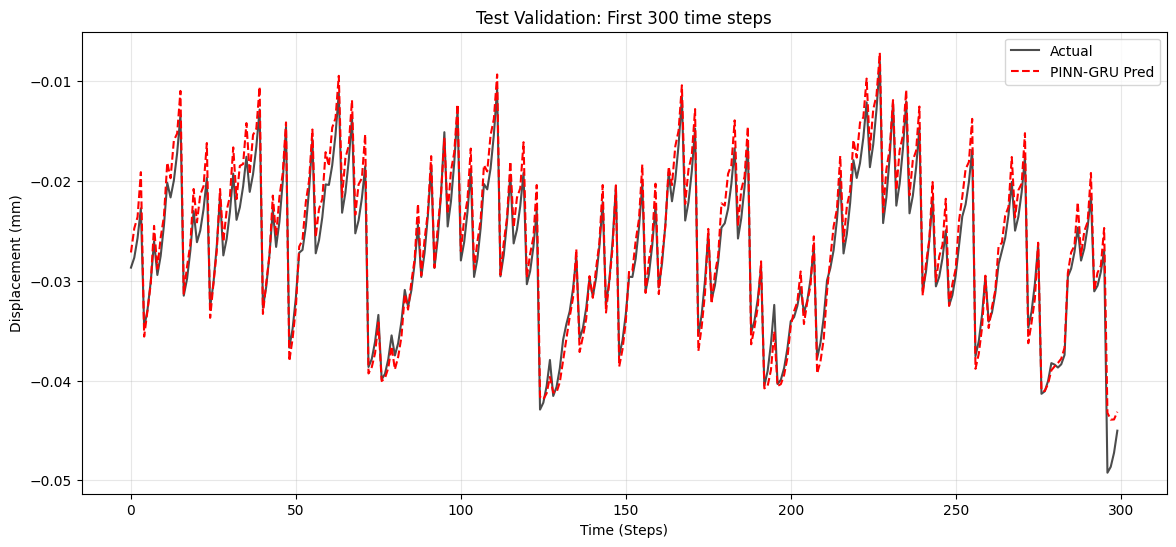

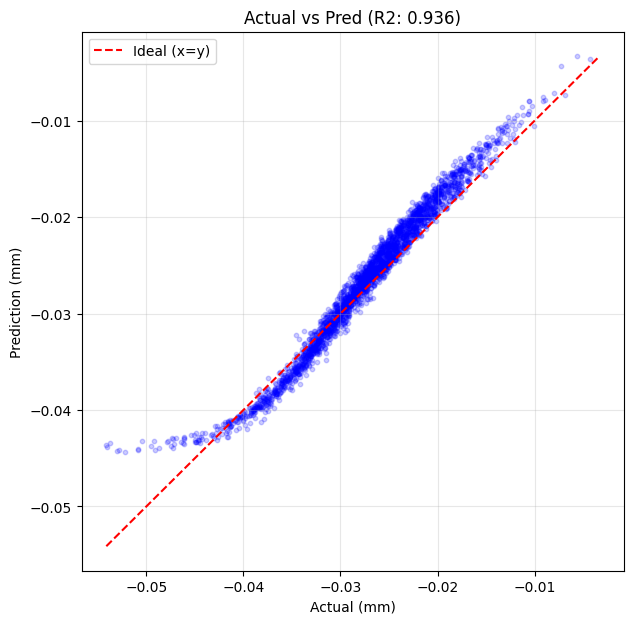


🌍 LEARNED GEOTECHNICAL PARAMETERS:
---------------------------------------------
Eta (Viscosity):       4.6814
Phi (Friction):        15.1870°
Cohesion (c'):         10.3422 kPa
Normal Stress (sn):    15.1361 kPa
Exponent (n):          1.0645
Shear Stress (tau):    15.0000 kPa (FIXED)
---------------------------------------------
🔍 PHYSICAL DIAGNOSIS:
Soil Resistance (Yield): 14.4509 kPa
Overstress (τ - τ_y):    0.5491 kPa
---------------------------------------------


In [13]:
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. FINAL EVALUATION
# Note: Pass U_MEAN and U_SCALE in the correct order for your StandardScaler
preds_final, targets_final = evaluate_model(test_loader, model, device, U_MEAN, U_SCALE)

# 2. METRICS
rmse = np.sqrt(mean_squared_error(targets_final, preds_final))
r2 = r2_score(targets_final, preds_final)
mae = mean_absolute_error(targets_final, preds_final)

print("\n--- 📊 TEST RESULTS ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.5f} mm")
print(f"MAE  (Mean Absolute Error):     {mae:.5f} mm")
print(f"R²   (Coefficient of Determ.):  {r2:.4f}")

# 3. PLOT 1: TIME SERIES (ZOOM)
limit = 300
plt.figure(figsize=(14, 6))
plt.plot(targets_final[:limit], label='Actual', color='black', alpha=0.7, linewidth=1.5)
plt.plot(preds_final[:limit], label='PINN-GRU Pred', color='red', linestyle='--', linewidth=1.5)
plt.title(f"Test Validation: First {limit} time steps")
plt.xlabel("Time (Steps)")
plt.ylabel("Displacement (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. PLOT 2: CORRELATION (SCATTER)
plt.figure(figsize=(7, 7))
plt.scatter(targets_final, preds_final, alpha=0.2, color='blue', s=10)

# Identity line (Perfect prediction)
min_val = min(targets_final.min(), preds_final.min())
max_val = max(targets_final.max(), preds_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (x=y)')

plt.xlabel("Actual (mm)")
plt.ylabel("Prediction (mm)")
plt.title(f"Actual vs Pred (R2: {r2:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. DETAILED GEOTECHNICAL REPORT
# Get final parameters calibrated by the network
final_params = soil_physics.get_params()

# Extract values (Use .item() only for tensors, tau is usually a fixed float)
# Note: If 'tau' or 'h' are fixed floats in your class, they don't use .item()
tau_val = final_params['tau'] if isinstance(final_params['tau'], float) else final_params['tau'].item()
sigma_n_val = final_params['sigma_n'].item()
c_val = final_params['c_prime'].item()
phi_val = final_params['phi'].item()
n_val = final_params['n'].item()
eta_val = final_params['eta'].item()

# Calculate Mohr-Coulomb Resistance (Yield Strength)
# tau_yield = c' + sigma_n * tan(phi)
tan_phi = math.tan(math.radians(phi_val))
tau_yield = c_val + (sigma_n_val * tan_phi)
overstress = tau_val - tau_yield

print("\n🌍 LEARNED GEOTECHNICAL PARAMETERS:")
print("-" * 45)
print(f"Eta (Viscosity):       {eta_val:.4f}")
print(f"Phi (Friction):        {phi_val:.4f}°")
print(f"Cohesion (c'):         {c_val:.4f} kPa")
print(f"Normal Stress (sn):    {sigma_n_val:.4f} kPa")
print(f"Exponent (n):          {n_val:.4f}")
print(f"Shear Stress (tau):    {tau_val:.4f} kPa (FIXED)")
print("-" * 45)

print(f"🔍 PHYSICAL DIAGNOSIS:")
print(f"Soil Resistance (Yield): {tau_yield:.4f} kPa")
print(f"Overstress (τ - τ_y):    {max(0, overstress):.4f} kPa")
print("-" * 45)